# Floating Lid Tank Depth Estimation

This notebook estimates the fill level of a floating-roof tank based on shadow geometry analysis in photos. It uses solar elevation angles and detected shadow lines to calculate the liquid height inside the tank.

## 1. Import Required Libraries

In [35]:
from datetime import datetime, timezone

import cv2
import matplotlib.pyplot as plt
import numpy as np
from pysolar.solar import get_altitude

## 2. Define Configuration Constants

In [58]:
# Calibration from a known reference image where wall height was measured manually.
DEFAULT_PIXELS_PER_METRE = 52.0

# Edge detection parameters - tune these to detect edges better
GAUSSIAN_KERNEL = (9, 9)  # Blur kernel size: (5,5), (7,7), (9,9), (11,11) - LARGER = more blur
CANNY_LOW_THRESHOLD = 20  # Lower threshold: edges with gradient below this are rejected (try 20-100)
CANNY_HIGH_THRESHOLD = 150  # Upper threshold: edges with gradient above this are kept (try 100-200)

# Line detection defaults tuned for typical tank images with strong rim/shadow contrast.
HOUGH_THRESHOLD = 100
HOUGH_MIN_LINE_LENGTH = 200
HOUGH_MAX_LINE_GAP = 20
MAX_HORIZONTAL_ANGLE_DEGREES = 10

## 3. Define Helper Functions

In [37]:
def _mid_y(line: tuple[int, int, int, int]) -> float:
    """Calculate the midpoint y-coordinate of a line."""
    return (line[1] + line[3]) / 2


def detect_horizontal_lines(gray: np.ndarray) -> list[tuple[int, int, int, int]]:
    """
    Detect horizontal lines in a grayscale image using edge detection and Hough line transform.
    
    Args:
        gray: Grayscale image
        
    Returns:
        List of horizontal lines represented as (x1, y1, x2, y2) tuples
    """
    blur = cv2.GaussianBlur(gray, GAUSSIAN_KERNEL, 0)
    edges = cv2.Canny(blur, CANNY_LOW_THRESHOLD, CANNY_HIGH_THRESHOLD)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=HOUGH_THRESHOLD,
        minLineLength=HOUGH_MIN_LINE_LENGTH,
        maxLineGap=HOUGH_MAX_LINE_GAP,
    )

    if lines is None:
        raise RuntimeError("No shadow lines detected.")

    horizontal_lines: list[tuple[int, int, int, int]] = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(angle) < MAX_HORIZONTAL_ANGLE_DEGREES:
            horizontal_lines.append((x1, y1, x2, y2))

    if not horizontal_lines:
        raise RuntimeError("No horizontal shadow lines found.")

    return horizontal_lines

## 4. Configuration Parameters

Adjust these parameters based on your specific tank and imaging setup:

In [38]:
# Input image path
IMAGE_PATH = "image.PNG"

# Tank dimensions in metres
TANK_HEIGHT = 22.0
TANK_DIAMETER = 80.0

# Geographic location of the tank
LATITUDE = 51.5074
LONGITUDE = -0.1278

# Image timestamp in UTC (ISO format)
TIMESTAMP_UTC = "2026-05-07T14:30:00"

# Pixel-to-metre calibration
PIXELS_PER_METRE = DEFAULT_PIXELS_PER_METRE

# Optional output settings
OUTPUT_IMAGE = ""  # Set to filename to save annotated output
DISPLAY_PLOT = True  # Set to False for headless environments

## 5. Load and Prepare Data

Load the tank image and validate input parameters:

In [39]:
# Validate parameters
if TANK_HEIGHT <= 0:
    raise ValueError("TANK_HEIGHT must be positive")
if TANK_DIAMETER <= 0:
    raise ValueError("TANK_DIAMETER must be positive")
if PIXELS_PER_METRE <= 0:
    raise ValueError("PIXELS_PER_METRE must be positive")

# Parse timestamp
timestamp = datetime.fromisoformat(TIMESTAMP_UTC)
if timestamp.tzinfo is None:
    timestamp = timestamp.replace(tzinfo=timezone.utc)
else:
    timestamp = timestamp.astimezone(timezone.utc)

print(f"Timestamp: {timestamp}")

# Load image
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

original = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"Image loaded: {img.shape}")

Timestamp: 2026-05-07 14:30:00+00:00
Image loaded: (455, 549, 3)


## 6. Process and Transform Data

Detect shadow lines and calculate fill level:

## 6a. Debug: Visualize Edge Detection

Visualize the intermediate steps to diagnose line detection issues:

Edge Detection Parameters:
  Gaussian Kernel: (9, 9)
  Canny Low Threshold: 20
  Canny High Threshold: 150

Tuning Guide:
  - To DETECT MORE edges: DECREASE thresholds or INCREASE kernel size
  - To DETECT FEWER edges: INCREASE thresholds or DECREASE kernel size
  - Kernel size affects smoothing: larger = smoother but less sharp


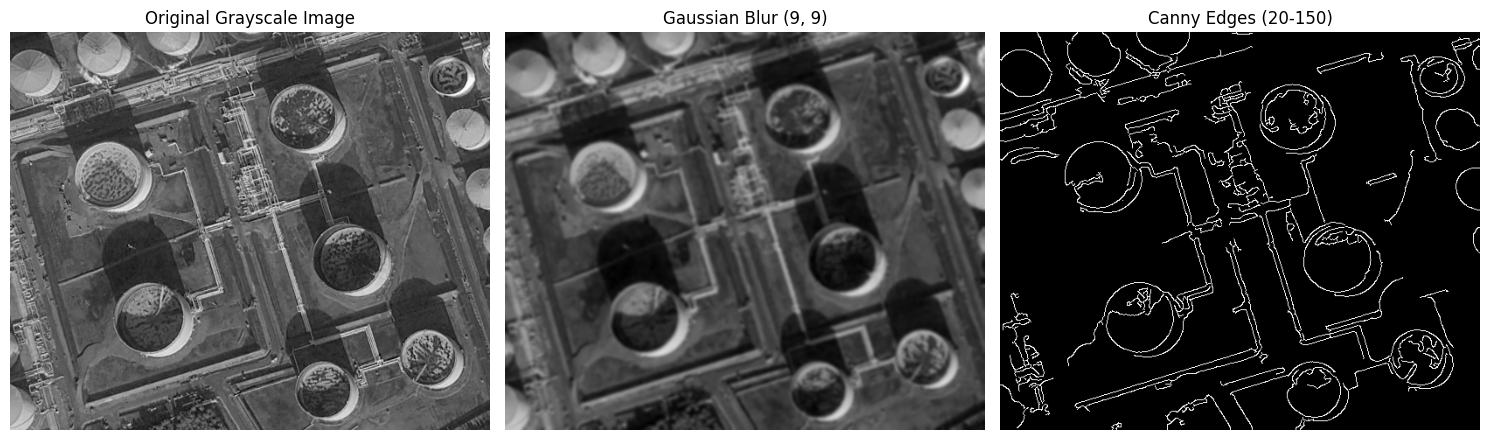


Edge pixels found: 13031


In [59]:
# Debug: Show edge detection steps
blur = cv2.GaussianBlur(gray, GAUSSIAN_KERNEL, 0)
edges = cv2.Canny(blur, CANNY_LOW_THRESHOLD, CANNY_HIGH_THRESHOLD)

print("Edge Detection Parameters:")
print(f"  Gaussian Kernel: {GAUSSIAN_KERNEL}")
print(f"  Canny Low Threshold: {CANNY_LOW_THRESHOLD}")
print(f"  Canny High Threshold: {CANNY_HIGH_THRESHOLD}")
print(f"\nTuning Guide:")
print(f"  - To DETECT MORE edges: DECREASE thresholds or INCREASE kernel size")
print(f"  - To DETECT FEWER edges: INCREASE thresholds or DECREASE kernel size")
print(f"  - Kernel size affects smoothing: larger = smoother but less sharp")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')

axes[1].imshow(blur, cmap='gray')
axes[1].set_title(f'Gaussian Blur {GAUSSIAN_KERNEL}')
axes[1].axis('off')

axes[2].imshow(edges, cmap='gray')
axes[2].set_title(f'Canny Edges ({CANNY_LOW_THRESHOLD}-{CANNY_HIGH_THRESHOLD})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nEdge pixels found: {np.count_nonzero(edges)}")

In [66]:
# Tuning parameters for HoughCircles detection
# Adjust these to filter out unwanted circles:
HOUGH_CIRCLES_DP = 1  # Inverse ratio of accumulator resolution (lower = more accurate)
HOUGH_CIRCLES_MIN_DIST = 10  # Minimum distance between circle centers
HOUGH_CIRCLES_PARAM1 = CANNY_HIGH_THRESHOLD  # Upper Canny edge threshold
HOUGH_CIRCLES_PARAM2 = 80  # Accumulator threshold (HIGHER = fewer circles, more strict)
HOUGH_CIRCLES_MIN_RADIUS = 10  # Minimum circle radius
HOUGH_CIRCLES_MAX_RADIUS = 400  # Maximum circle radius

print("HoughCircles parameters:")
print(f"  param2 (accumulator threshold): {HOUGH_CIRCLES_PARAM2} <- INCREASE to reject extra circles")
print(f"  minRadius: {HOUGH_CIRCLES_MIN_RADIUS}")
print(f"  maxRadius: {HOUGH_CIRCLES_MAX_RADIUS}")

# Detect circles in the edge image using Hough Circle Detection
circles = cv2.HoughCircles(
    edges,
    cv2.HOUGH_GRADIENT,
    dp=HOUGH_CIRCLES_DP,
    minDist=HOUGH_CIRCLES_MIN_DIST,
    param1=HOUGH_CIRCLES_PARAM1,
    param2=HOUGH_CIRCLES_PARAM2,
    minRadius=HOUGH_CIRCLES_MIN_RADIUS,
    maxRadius=HOUGH_CIRCLES_MAX_RADIUS
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    print(f"\nCircles detected: {circles.shape[2]}")
    print(f"Circle parameters (x, y, radius):")
    for i, circle in enumerate(circles[0]):
        print(f"  Circle {i+1}: Center: ({circle[0]}, {circle[1]}), Radius: {circle[2]}")
else:
    print("No circles detected in the edge image")
    circles = np.array([])

HoughCircles parameters:
  param2 (accumulator threshold): 80 <- INCREASE to reject extra circles
  minRadius: 10
  maxRadius: 400

Circles detected: 3
Circle parameters (x, y, radius):
  Circle 1: Center: (386, 256), Radius: 39
  Circle 2: Center: (112, 162), Radius: 38
  Circle 3: Center: (162, 328), Radius: 42
  Circle 4: Center: (332, 96), Radius: 38


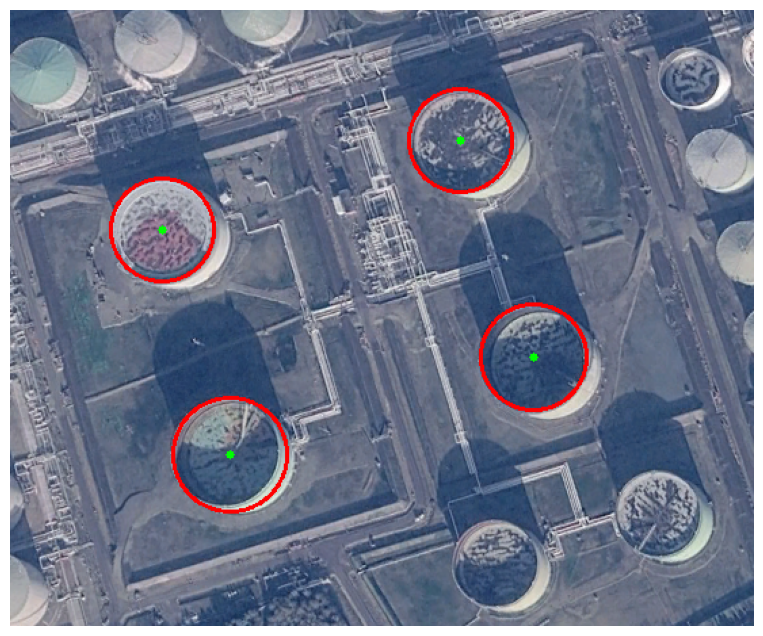

In [67]:
# Overlay detected circles on the original image and display/save result.
overlay = original.copy()

# Draw circles from `circles` (HoughCircles output, shape (1, N, 3))
if 'circles' in globals() and isinstance(circles, np.ndarray) and circles.size:
    for c in circles[0]:
        x, y, r = int(c[0]), int(c[1]), int(c[2])
        cv2.circle(overlay, (x, y), r, (0, 0, 255), 2)  # red circumference (BGR)
        cv2.circle(overlay, (x, y), 3, (0, 255, 0), -1)  # green center

# Update annotated image variable and optionally save/display
annotated = overlay

if OUTPUT_IMAGE:
    cv2.imwrite(OUTPUT_IMAGE, overlay)

if DISPLAY_PLOT:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [ ]:
## 6b. Detect Shadow Contours Inside Tank Circles

Find shadow contours within each detected circular tank area:

Analyzing 4 tank circles for shadow contours (concentric arcs)...

Arc Detection Parameters (lenient settings):
  Min Area: 1
  Min Perimeter: 1
  Min Circularity: 0.1
  Max Concentricity: 1.0x tank radius
  Radius Tolerance: ±15% of tank radius

Circle 1: Center (386, 256), Radius 39
  Contours found: 10
  Shadow arcs found: 0
Circle 2: Center (112, 162), Radius 38
  Contours found: 10
  Shadow arcs found: 0
Circle 3: Center (162, 328), Radius 42
  Contours found: 10
  Shadow arcs found: 0
Circle 4: Center (332, 96), Radius 38
  Contours found: 11
  Shadow arcs found: 0

Total shadow arcs found: 0


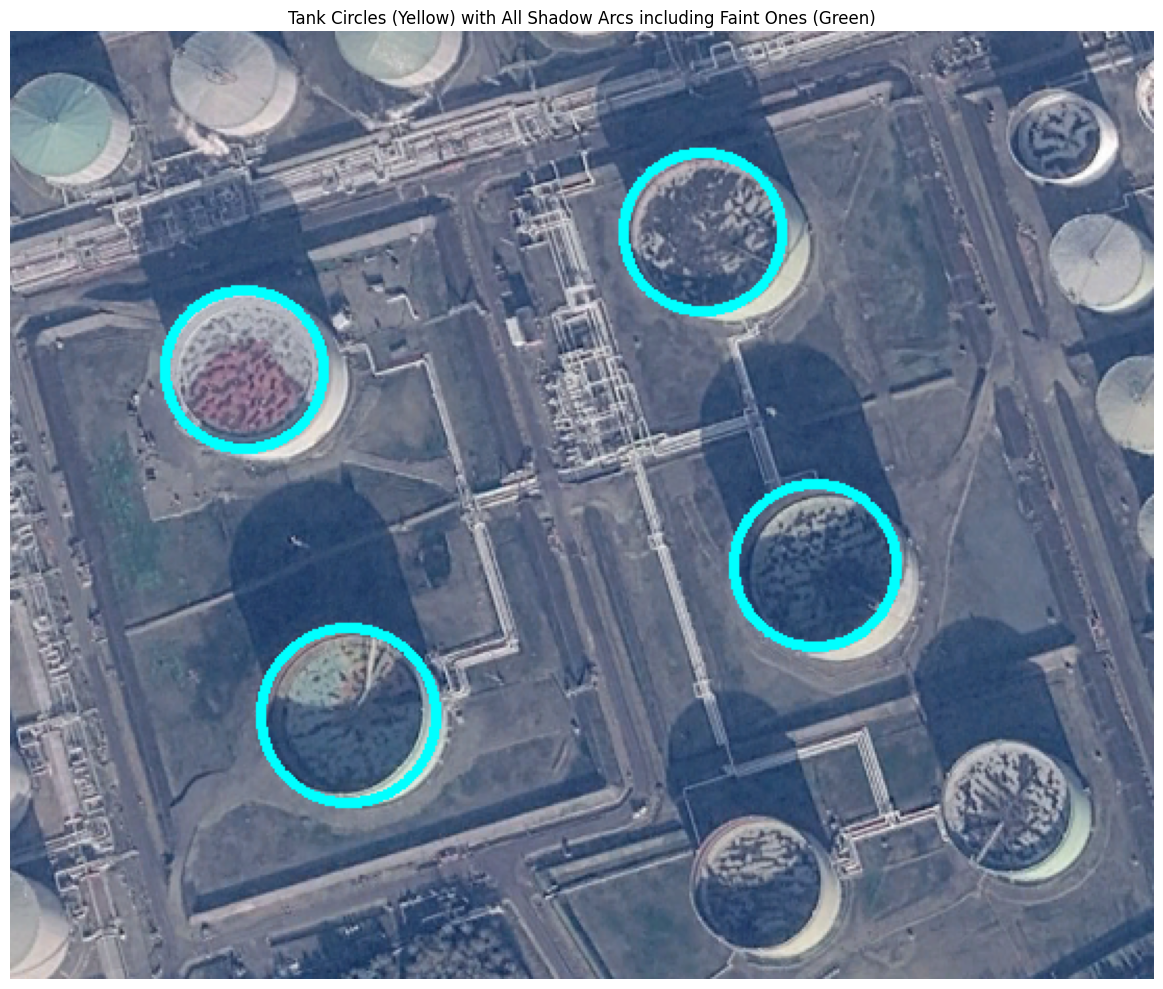

In [81]:
if circles is not None and circles.size > 0:
    print(f"Analyzing {len(circles[0])} tank circles for shadow contours (concentric arcs)...\n")
    
    all_shadow_contours = []
    
    # Tuning parameters for arc detection - make lenient to catch faint rings
    MIN_ARC_AREA = 1  # Minimum contour area (lower = catch fainter arcs)
    MIN_ARC_PERIMETER = 1  # Minimum contour perimeter (lower = catch fainter arcs)
    MIN_CIRCULARITY = 0.1  # Minimum circularity threshold (very lenient - accepts non-circular shapes)
    MAX_CONCENTRICITY_RATIO = 1.0  # How far from tank center (1.0 = entire tank radius tolerance)
    RADIUS_TOLERANCE_PERCENT = 15  # Arc radius should be within ±15% of tank radius
    
    print(f"Arc Detection Parameters (lenient settings):")
    print(f"  Min Area: {MIN_ARC_AREA}")
    print(f"  Min Perimeter: {MIN_ARC_PERIMETER}")
    print(f"  Min Circularity: {MIN_CIRCULARITY}")
    print(f"  Max Concentricity: {MAX_CONCENTRICITY_RATIO}x tank radius")
    print(f"  Radius Tolerance: ±{RADIUS_TOLERANCE_PERCENT}% of tank radius\n")
    
    for circle_idx, (tank_cx, tank_cy, tank_cr) in enumerate(circles[0]):
        print(f"Circle {circle_idx + 1}: Center ({tank_cx}, {tank_cy}), Radius {tank_cr}")
        
        # Create a mask for this circle
        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (tank_cx, tank_cy), tank_cr, 255, -1)
        
        # Extract region inside circle
        circle_region = cv2.bitwise_and(edges, edges, mask=mask)
        
        # Find contours in this region
        contours, _ = cv2.findContours(circle_region, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        
        print(f"  Contours found: {len(contours)}")
        
        # Filter for concentric circular/arc contours (shadow lines)
        shadow_arcs = []
        for contour in contours:
            # Get contour properties
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, False)
            
            # Skip very small contours (lenient threshold)
            if area < MIN_ARC_AREA or perimeter < MIN_ARC_PERIMETER:
                continue
            
            # Fit circle to contour to check if it's circular
            (cx, cy), radius = cv2.minEnclosingCircle(contour)
            
            # Calculate circularity (how circular the contour is)
            # Perfect circle: circularity = 1.0
            if perimeter > 0:
                circularity = 4 * np.pi * area / (perimeter ** 2)
            else:
                circularity = 0
            
            # Check if contour is roughly concentric with tank (similar center)
            dist_to_tank_center = np.sqrt((cx - tank_cx)**2 + (cy - tank_cy)**2)
            
            # Check if arc radius is similar to tank radius
            radius_diff_percent = abs(radius - tank_cr) / tank_cr * 100
            
            # Accept if:
            # 1. It's somewhat circular (very lenient threshold)
            # 2. It's roughly concentric with tank center
            # 3. Its radius is similar to tank radius (within tolerance)
            if (circularity > MIN_CIRCULARITY and 
                dist_to_tank_center < (tank_cr * MAX_CONCENTRICITY_RATIO) and
                radius_diff_percent < RADIUS_TOLERANCE_PERCENT):
                shadow_arcs.append({
                    'contour': contour,
                    'center_x': cx,
                    'center_y': cy,
                    'radius': radius,
                    'area': area,
                    'perimeter': perimeter,
                    'circularity': circularity,
                    'dist_to_tank_center': dist_to_tank_center,
                    'radius_diff_percent': radius_diff_percent,
                    'circle_idx': circle_idx
                })
        
        print(f"  Shadow arcs found: {len(shadow_arcs)}")
        for i, arc in enumerate(shadow_arcs):
            print(f"    {i+1}. Center: ({arc['center_x']:.0f}, {arc['center_y']:.0f}), Radius: {arc['radius']:.0f} (tank: {tank_cr}), Diff: {arc['radius_diff_percent']:.1f}%, Circularity: {arc['circularity']:.3f}")
        
        all_shadow_contours.extend(shadow_arcs)
    
    print(f"\nTotal shadow arcs found: {len(all_shadow_contours)}")
    
    # Visualize the results
    viz_img = original.copy()
    
    # Draw tank circles
    for cx, cy, cr in circles[0]:
        cv2.circle(viz_img, (cx, cy), cr, (255, 255, 0), 3)  # Yellow circles - tank boundaries
    
    # Draw shadow arcs in green with varying brightness based on strength
    for arc_data in all_shadow_contours:
        # Draw the arc contour
        cv2.drawContours(viz_img, [arc_data['contour']], 0, (0, 255, 0), 2)
        # Draw the fitted circle around the arc
        cv2.circle(viz_img, (int(arc_data['center_x']), int(arc_data['center_y'])), 
                   int(arc_data['radius']), (0, 200, 0), 1)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Tank Circles (Yellow) with All Shadow Arcs including Faint Ones (Green)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No circles detected. Run circle detection first.")

## 6c. Identify Lid Edge (Strongest Contrast Arc)

Find the most prominent arc - the interface between floating lid and tank wall:

Analyzing 5 shadow arcs to find lid edge...

Shadow arcs ranked by characteristics (top candidates for lid edge):

1. Tank 4: Radius=6px, Circularity=0.339, Mean Edge Strength=255, Area=42, Edge Count=26
2. Tank 4: Radius=2px, Circularity=1.048, Mean Edge Strength=255, Area=11, Edge Count=7
3. Tank 3: Radius=2px, Circularity=1.298, Mean Edge Strength=255, Area=8, Edge Count=7
4. Tank 4: Radius=4px, Circularity=1.417, Mean Edge Strength=255, Area=30, Edge Count=9
5. Tank 3: Radius=2px, Circularity=1.572, Mean Edge Strength=255, Area=8, Edge Count=7

✓ IDENTIFIED LID EDGE (strongest contrast):
  Tank Circle: 3
  Arc Radius: 2.1 pixels
  Arc Center: (146.5, 310.0)
  Edge Strength: 255
  Circularity: 1.572
  Area: 8


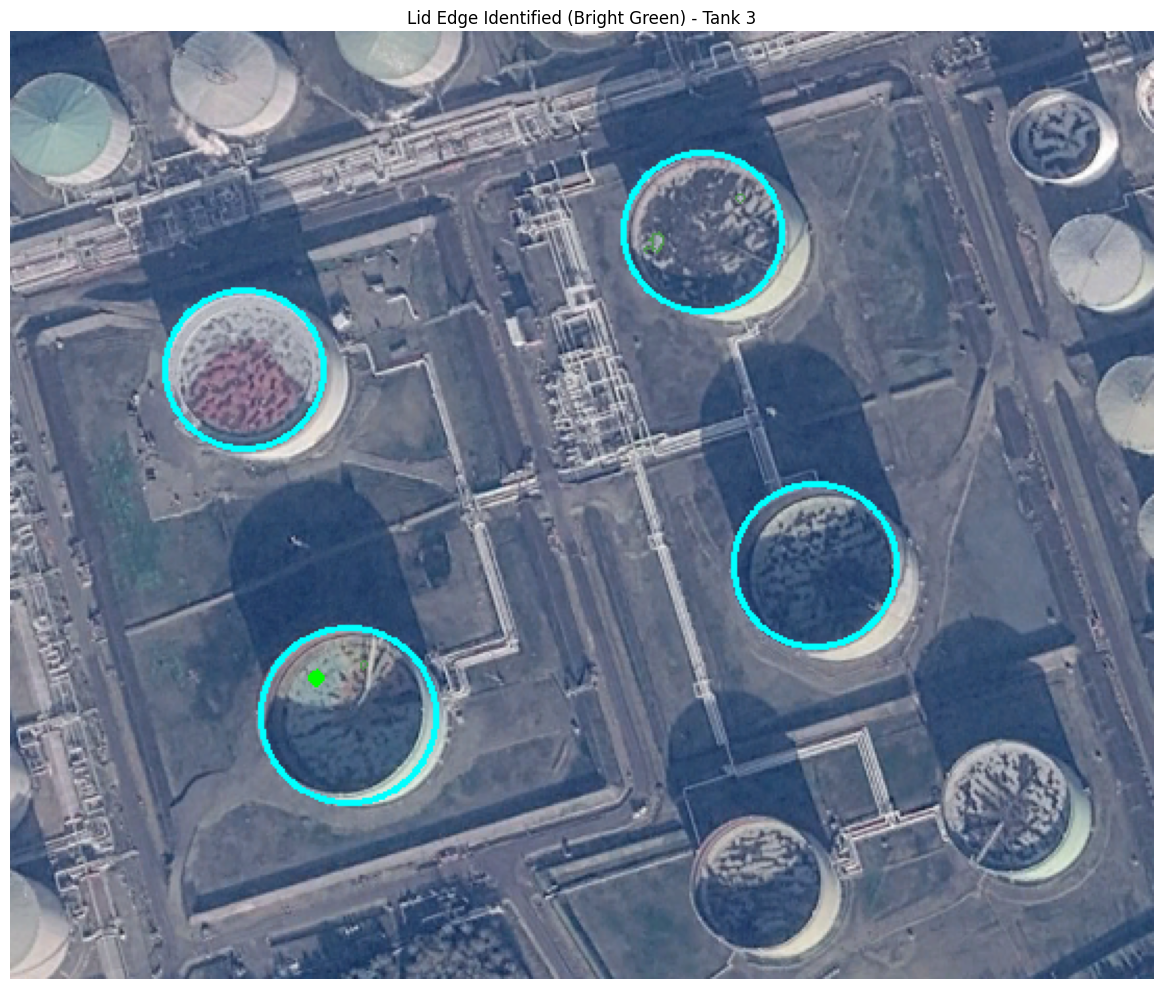

In [79]:
if 'all_shadow_contours' in locals() and len(all_shadow_contours) > 0:
    print(f"Analyzing {len(all_shadow_contours)} shadow arcs to find lid edge...\n")
    
    # For each shadow arc, calculate edge strength/contrast
    for arc in all_shadow_contours:
        contour = arc['contour']
        
        # Calculate edge strength along the contour
        # Extract pixel values along the contour
        edge_strengths = []
        for point in contour:
            x, y = point[0]
            if 0 <= y < edges.shape[0] and 0 <= x < edges.shape[1]:
                edge_strengths.append(edges[y, x])
        
        if edge_strengths:
            arc['max_edge_strength'] = np.max(edge_strengths)
            arc['mean_edge_strength'] = np.mean(edge_strengths)
            arc['edge_count'] = np.count_nonzero(edge_strengths)
        else:
            arc['max_edge_strength'] = 0
            arc['mean_edge_strength'] = 0
            arc['edge_count'] = 0
    
    # Sort by multiple criteria to find lid edge:
    # 1. Primary: edge strength (brightness)
    # 2. Secondary: circularity (lid edge should be fairly circular)
    # 3. Tertiary: radius (lid edge has intermediate radius, not too small/large)
    sorted_arcs = sorted(all_shadow_contours, 
                        key=lambda x: (x['mean_edge_strength'], x['circularity'], 
                                     -abs(x['radius'] - 200)),  # prefer mid-range radius
                        reverse=False)
    
    print("Shadow arcs ranked by characteristics (top candidates for lid edge):\n")
    for i, arc in enumerate(sorted_arcs[-10:]):  # Show top 10
        print(f"{i+1}. Tank {arc['circle_idx']+1}: Radius={arc['radius']:.0f}px, "
              f"Circularity={arc['circularity']:.3f}, "
              f"Mean Edge Strength={arc['mean_edge_strength']:.0f}, "
              f"Area={arc['area']:.0f}, Edge Count={arc['edge_count']}")
    
    # The lid edge is typically the one with strongest edge combined with good circularity
    if sorted_arcs:
        lid_arc = sorted_arcs[-1]  # Highest ranked
        print(f"\n✓ IDENTIFIED LID EDGE (strongest contrast):")
        print(f"  Tank Circle: {lid_arc['circle_idx'] + 1}")
        print(f"  Arc Radius: {lid_arc['radius']:.1f} pixels")
        print(f"  Arc Center: ({lid_arc['center_x']:.1f}, {lid_arc['center_y']:.1f})")
        print(f"  Edge Strength: {lid_arc['mean_edge_strength']:.0f}")
        print(f"  Circularity: {lid_arc['circularity']:.3f}")
        print(f"  Area: {lid_arc['area']:.0f}")
        
        # Visualize with lid edge highlighted and all candidates shown
        viz_img = original.copy()
        
        # Draw all arcs in faint green (candidates)
        for i, arc in enumerate(sorted_arcs[:-1]):
            # Fade weaker arcs
            cv2.drawContours(viz_img, [arc['contour']], 0, (80, 150, 80), 1)
        
        # Draw lid edge in bright green
        cv2.drawContours(viz_img, [lid_arc['contour']], 0, (0, 255, 0), 3)
        cv2.circle(viz_img, (int(lid_arc['center_x']), int(lid_arc['center_y'])), 
                   int(lid_arc['radius']), (0, 255, 0), 2)
        
        # Draw tank circles
        for cx, cy, cr in circles[0]:
            cv2.circle(viz_img, (cx, cy), cr, (255, 255, 0), 2)
        
        plt.figure(figsize=(14, 10))
        plt.imshow(cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Lid Edge Identified (Bright Green) - Tank {lid_arc['circle_idx']+1}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("No shadow arcs detected. Run shadow arc detection first.")